# Spurious Correlation Analysis: Swimming Pool Drownings vs. Nicolas Cage Films
## Import Required Libraries

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np

## Define the Dataset
The real data from Tyler Vigen (2000 - 2009): the number of swimming pool drownings in the US and the number of films Nicolas Cage appeared in.

In [ ]:
data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009],
    "Pool_Drownings": [109, 102, 102, 98, 85, 95, 96, 98, 123, 94],
    "Nicolas_Cage_Films": [2, 2, 2, 3, 1, 1, 2, 3, 4, 1],
}

df = pd.DataFrame(data)
df

,Jaar,Verdrinkingen_Zwembad,Nicolas_Cage_Films
0,2000,109,2
1,2001,102,2
2,2002,102,2
3,2003,98,3
4,2004,85,1
5,2005,95,1
6,2006,96,2
7,2007,98,3
8,2008,123,4
9,2009,94,1


## Explore Data
View the basic statistics of the dataset.

In [6]:
print(df.describe())
print("\n")
df.info()

             Jaar  Verdrinkingen_Zwembad  Nicolas_Cage_Films
count    10.00000              10.000000           10.000000
mean   2004.50000             100.200000            2.100000
std       3.02765              10.152175            0.994429
min    2000.00000              85.000000            1.000000
25%    2002.25000              95.250000            1.250000
50%    2004.50000              98.000000            2.000000
75%    2006.75000             102.000000            2.750000
max    2009.00000             123.000000            4.000000


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Jaar                   10 non-null     int64
 1   Verdrinkingen_Zwembad  10 non-null     int64
 2   Nicolas_Cage_Films     10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


## Calculate Correlation Coefficient
Calculate the Pearson correlation coefficient between swimming pool drownings and Nicolas Cage films.

In [ ]:
correlation = df["Pool_Drownings"].corr(df["Nicolas_Cage_Films"])
print(f"The correlation coefficient is: {correlation:.2f}")

De correlatiecoëfficiënt is: 0.75


## Visualize with Dual Y-Axis Plot
Create a chart with two Y-axes: drownings (red, left) and Nicolas Cage films (blue, right).

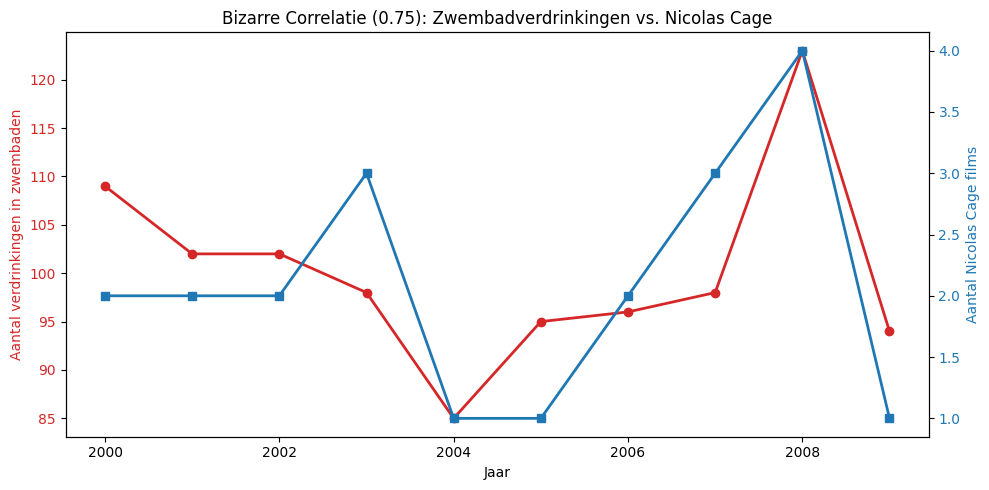

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:red"
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Swimming Pool Drownings", color=color)
ax1.plot(df["Year"], df["Pool_Drownings"], color=color, marker="o", linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Number of Nicolas Cage Films", color=color)
ax2.plot(df["Year"], df["Nicolas_Cage_Films"], color=color, marker="s", linewidth=2)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    f"Bizarre Correlation ({correlation:.2f}): Pool Drownings vs. Nicolas Cage Films"
)
fig.tight_layout()
plt.show()

## Statistical Significance Test
Use scipy.stats.pearsonr to calculate the p-value and determine whether the correlation is statistically significant.

In [ ]:
r, p_value = stats.pearsonr(df["Pool_Drownings"], df["Nicolas_Cage_Films"])
print(f"Pearson correlation: r = {r:.4f}")
print(f"P-value: p = {p_value:.4f}")
print(f"\nStatistically significant (p < 0.05)? {'Yes' if p_value < 0.05 else 'No'}")
print(f"\nDespite the correlation being {'statistically significant' if p_value < 0.05 else 'not significant'},")
print("this does NOT mean Nicolas Cage films cause drownings!")

Pearson correlatie: r = 0.7462
P-waarde: p = 0.0132

Statistisch significant (p < 0.05)? Ja

Ondanks dat de correlatie wel statistisch significant is,
betekent dit NIET dat Nicolas Cage films verdrinkingen veroorzaken!


## Spurious Correlations: Correlation ≠ Causation
A scatter plot with a regression line to visually examine the relationship, plus an explanation of why correlation does not imply causation.

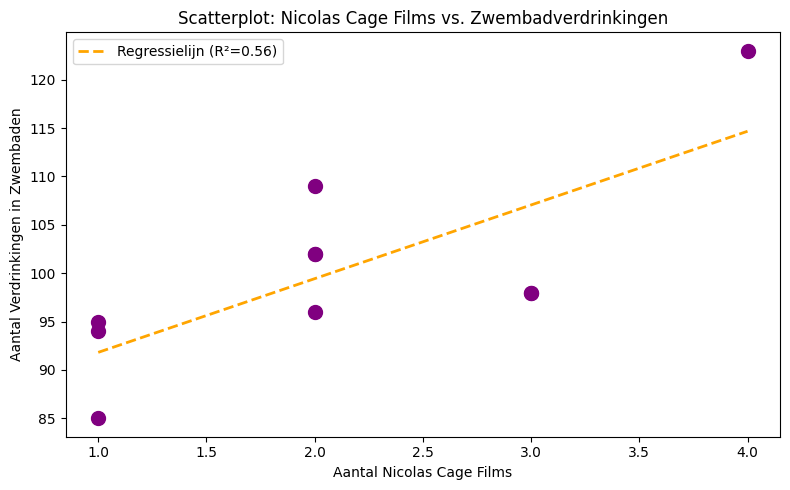


WAAROM CORRELATIE GEEN CAUSALITEIT IMPLICEERT

Dit is een klassiek voorbeeld van een 'spurious correlation' 
(schijncorrelatie). De hoge correlatie tussen het aantal Nicolas 
Cage films en zwembadverdrinkingen is puur toeval.

Mogelijke verklaringen voor spurious correlaties:
1. Toeval - bij genoeg variabelen vind je altijd correlaties
2. Confounders - een derde variabele beïnvloedt beide
3. Trends - beide variabelen volgen dezelfde tijdstrend

Bron: Tyler Vigen - tylervigen.com/spurious-correlations



In [ ]:
# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Nicolas_Cage_Films"], df["Pool_Drownings"], color="purple", s=100, zorder=5)

# Regression line
slope, intercept, r_value, p_val, std_err = stats.linregress(
    df["Nicolas_Cage_Films"], df["Pool_Drownings"]
)
x_line = np.linspace(df["Nicolas_Cage_Films"].min(), df["Nicolas_Cage_Films"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="orange", linewidth=2, linestyle="--", label=f"Regression line (R²={r_value**2:.2f})")

ax.set_xlabel("Number of Nicolas Cage Films")
ax.set_ylabel("Number of Swimming Pool Drownings")
ax.set_title("Scatter Plot: Nicolas Cage Films vs. Pool Drownings")
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("WHY CORRELATION DOES NOT IMPLY CAUSATION")
print("="*60)
print("""
This is a classic example of a 'spurious correlation'. 
The high correlation between the number of Nicolas Cage 
films and swimming pool drownings is purely coincidental.

Possible explanations for spurious correlations:
1. Coincidence - with enough variables you'll always find correlations
2. Confounders - a third variable influences both
3. Trends - both variables follow the same time trend

Source: Tyler Vigen - tylervigen.com/spurious-correlations
""")